# Ω cell cover by adaptive refinement using lemma-based lower bounds (from saved interpolation)

このノートは `interpolation_model.pkl` に保存された **λ₁ の補間器**を読み込み、  
次のアルゴリズムで Ω（`(x,θ)` 表現）をセルで被覆します。

---

## アルゴリズム（ユーザ指定）

1. `x, θ` を **原子セル**に分割（初期グリッド）
2. 各セルで **下界評価式**を計算  
   $$
     J_{1,\mathrm{lb}}(C)=B_1(p_{i+1,j};\lambda(p_{i+1,j+1})),\qquad
     J_{2,\mathrm{lb}}(C)=B_2(p_{i+1,j};\lambda(p_{i+1,j+1}))
   $$
3. 下界が **負（あるいは閾値未満）**になったセルだけ **再分割**
4. 2–3 を繰り返す

---

## 重要な注意（必ず読んでください）

- ここでの `λ` は **補間値**です。補間は一般に「下界」ではないため、  
  この `J_lb` は「真の下界」とは限りません（偽陽性/偽陰性の可能性があります）。
- `(x,θ)` の長方形セルは Ω の曲線境界 `θ=arccos(x)` を跨ぐことがあるので、  
  評価点を Ω 内に射影（clamp）するオプションを用意しています。  
  ただし射影は Lemma の前提を厳密には崩し得ます。必要に応じて切り替えてください。

---

## 出力

- `cells_scored`: 最終セル（葉）のリスト `[(CellXT, score_dict), ...]`
- 可視化（`(x,θ)` と `(x,y)`）
- CSV 書き出し（指定スキーマ）

In [1]:
# 0. Imports
import math
import time
import sys
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

## 1. Parameters

In [ ]:
# 1. Parameters (EDIT HERE)

MODEL_PATH = "interpolation_model.pkl"   # joblib file

# Ω definition in (x,θ): x∈[1/2,1], θ∈(0, arccos(x)].
x_min = 0.5
x_max = 1.0
theta_cap = math.acos(0.5)              # π/3
theta_low = math.asin(0.05)             # avoid degeneracy (match your old setting)

# refinement loop
Nx0 = 5          # initial bins in x  (atomic grid)
Nt0 = 5          # initial bins in θ
MAX_ROUNDS = 20   # refinement rounds
MAX_DEPTH = 24    # hard depth cap (safety)

# split control
SPLIT_MODE = "adaptive"  # "adaptive" (split x or θ) or "quad" (split both => 4 children)
min_dx = 1e-6
min_dt = 1e-6

# feasibility threshold: refine if J_lb < eps_J
eps_J = 0.0       # set to 1e-8, 1e-6, ... to enforce margin

# optional excluded ball around equilateral point p*=(1/2, √3/2)
exclude_eps_xy = 0.12     # e.g. 1e-2. 0 disables.

# evaluation-point projection (clamp) into Ω
USE_PROJECTION = True
theta_proj_eps = 1e-12   # used only if USE_PROJECTION=True

# progress reporting
SHOW_PROGRESS = True
PROGRESS_EVERY_SEC = 0.3



print("theta_cap =", theta_cap, "| theta_low =", theta_low)

theta_cap = 1.0471975511965976 | theta_low = 0.050020856805770016


## 2. Load interpolation model

In [3]:
loaded = joblib.load(MODEL_PATH)
if isinstance(loaded, dict) and "interp" in loaded:
    interp: Dict[str, Callable] = loaded["interp"]
else:
    interp = loaded

assert isinstance(interp, dict) and ("lambda1" in interp), "interp must contain key 'lambda1'"
print("Loaded interp keys:", list(interp.keys()))

Loaded interp keys: ['lambda1', 'J1', 'J2']


## 3. Geometry + J functions

In [4]:
def theta_max(x: float) -> float:
    x = float(x)
    x = min(max(x, -1.0), 1.0)
    return math.acos(x)

def xt_to_xy(x: float, th: float) -> Tuple[float, float]:
    return float(x), float(x * math.tan(th))

def project_xt_to_Omega(x: float, th: float) -> Tuple[float, float]:
    """
    Clamp evaluation point into Ω:
      x -> [x_min, x_max]
      θ -> [theta_low, theta_max(x)-theta_proj_eps]
    """
    x = float(min(max(x, x_min), x_max))
    th_hi = theta_max(x) - theta_proj_eps
    th_hi = max(th_hi, theta_low)
    th = float(min(max(th, theta_low), th_hi))
    return x, th

def xt_to_xy_in_Omega(x: float, th: float) -> Tuple[float, float]:
    if not USE_PROJECTION:
        return xt_to_xy(x, th)
    x2, th2 = project_xt_to_Omega(x, th)
    return xt_to_xy(x2, th2)

def triangle_area_perimeter(x: float, y: float) -> Tuple[float, float]:
    area = abs(y) * 0.5
    per = 1.0 + math.hypot(x, y) + math.hypot(x - 1.0, y)
    return area, per

# J1, J2 lower-bound kernels B1, B2 (your latest J2 formula)
def B1(p_xy: Tuple[float, float], Lambda: float) -> float:
    x, y = float(p_xy[0]), float(p_xy[1])
    area, per = triangle_area_perimeter(x, y)
    return Lambda * area - (math.pi**2 / 16.0) * (per**2 / area) - (7.0 * math.sqrt(3.0) * math.pi**2 / 12.0)

def B2(p_xy: Tuple[float, float], Lambda: float) -> float:
    x, y = float(p_xy[0]), float(p_xy[1])
    area, per = triangle_area_perimeter(x, y)
    C = (4.0 * math.pi**2) / (3.0 + math.sqrt(math.pi * math.sqrt(3.0)))**2
    return Lambda * area - C * ((per + math.sqrt(4.0 * math.pi * area))**2) / (4.0 * area)

def eval_lambda1_xy(pts_xy: np.ndarray) -> np.ndarray:
    return np.asarray(interp["lambda1"](pts_xy), dtype=float)

## 4. Cell class + Ω intersection + excluded ball

In [5]:
@dataclass(frozen=True)
class CellXT:
    xL: float
    xR: float
    tL: float
    tR: float
    depth: int = 0

    def width(self) -> float:
        return float(self.xR - self.xL)

    def height(self) -> float:
        return float(self.tR - self.tL)

    def split_x(self):
        xm = 0.5 * (self.xL + self.xR)
        return (
            CellXT(self.xL, xm, self.tL, self.tR, self.depth + 1),
            CellXT(xm, self.xR, self.tL, self.tR, self.depth + 1),
        )

    def split_t(self):
        tm = 0.5 * (self.tL + self.tR)
        return (
            CellXT(self.xL, self.xR, self.tL, tm, self.depth + 1),
            CellXT(self.xL, self.xR, tm, self.tR, self.depth + 1),
        )

    def split_quad(self):
        (c1, c2) = self.split_x()
        return c1.split_t() + c2.split_t()

def cell_intersects_Omega(cell: CellXT) -> bool:
    # overlap with bounding box
    if cell.xR <= x_min or cell.xL >= x_max:
        return False
    if cell.tR <= theta_low or cell.tL >= theta_cap:
        return False
    # need existence x in [xL,xR] with tL < acos(x)
    xL_eff = max(cell.xL, x_min)
    if cell.tL >= theta_max(xL_eff):
        return False
    return True

# --- excluded ball around p* in (x,y) ---
PSTAR = np.array([0.5, math.sqrt(3)/2], dtype=float)

def cell_vertices_xy(cell: CellXT) -> np.ndarray:
    x0, x1, t0, t1 = cell.xL, cell.xR, cell.tL, cell.tR
    return np.array([
        xt_to_xy_in_Omega(x0, t0),
        xt_to_xy_in_Omega(x1, t0),
        xt_to_xy_in_Omega(x1, t1),
        xt_to_xy_in_Omega(x0, t1),
    ], dtype=float)

def _point_in_poly(p: np.ndarray, poly: np.ndarray) -> bool:
    x, y = float(p[0]), float(p[1])
    inside = False
    n = poly.shape[0]
    for i in range(n):
        x1, y1 = float(poly[i,0]), float(poly[i,1])
        x2, y2 = float(poly[(i+1)%n,0]), float(poly[(i+1)%n,1])
        if ((y1 > y) != (y2 > y)):
            x_int = (x2 - x1) * (y - y1) / (y2 - y1 + 1e-300) + x1
            if x < x_int:
                inside = not inside
    return inside

def _dist_point_segment(p: np.ndarray, a: np.ndarray, b: np.ndarray) -> float:
    ap = p - a
    ab = b - a
    denom = float(np.dot(ab, ab))
    if denom <= 1e-300:
        return float(np.linalg.norm(ap))
    t = float(np.dot(ap, ab) / denom)
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def dist_point_polygon(p: np.ndarray, poly: np.ndarray) -> float:
    if _point_in_poly(p, poly):
        return 0.0
    n = poly.shape[0]
    d = float("inf")
    for i in range(n):
        a = poly[i]
        b = poly[(i+1)%n]
        d = min(d, _dist_point_segment(p, a, b))
    return float(d)

def cell_vertices_xy_raw(cell: CellXT) -> np.ndarray:
    x0, x1, t0, t1 = cell.xL, cell.xR, cell.tL, cell.tR
    return np.array([xt_to_xy(x0,t0), xt_to_xy(x1,t0), xt_to_xy(x1,t1), xt_to_xy(x0,t1)], float)

def cell_touches_excluded_ball(cell: CellXT, eps: float) -> bool:
    if eps <= 0.0:
        return False
    poly = cell_vertices_xy_raw(cell)
    d = dist_point_polygon(PSTAR, poly)
    return d <= eps

## 5. Lemma-based lower bounds per cell

In [6]:
def cell_bounds_from_lemma(cell: CellXT) -> Dict[str, float]:
    """
    Your evaluation:
      p_ij    = (xL, tL)
      p_i1j   = (xR, tL)
      p_ij1   = (xL, tR)
      p_i1j1  = (xR, tR)

      lam_i1j1 = λ(p_i1j1)
      lam_ij   = λ(p_ij)

      J_lb = B(p_i1j ; lam_i1j1)
      J_ub = B(p_ij1 ; lam_ij)   (optional; not used in refinement)
    """
    xL, xR, tL, tR = float(cell.xL), float(cell.xR), float(cell.tL), float(cell.tR)

    # p_ij_xy   = xt_to_xy_in_Omega(xL, tL)
    # p_i1j_xy  = xt_to_xy_in_Omega(xR, tL)
    # p_ij1_xy  = xt_to_xy_in_Omega(xL, tR)
    # p_i1j1_xy = xt_to_xy_in_Omega(xR, tR)

    p_ij_xy   = xt_to_xy(xL, tL)
    p_i1j_xy  = xt_to_xy(xR, tL)
    p_ij1_xy  = xt_to_xy(xL, tR)
    p_i1j1_xy = xt_to_xy(xR, tR)

    lam_i1j1 = float(eval_lambda1_xy(np.array([p_i1j1_xy], dtype=float))[0])
    lam_ij   = float(eval_lambda1_xy(np.array([p_ij_xy], dtype=float))[0])

    if (not np.isfinite(lam_i1j1)) or (not np.isfinite(lam_ij)):
        return {"nan": 1.0}

    J1_lb = float(B1(p_i1j_xy, lam_i1j1))
    J2_lb = float(B2(p_i1j_xy, lam_i1j1))
    J1_ub = float(B1(p_ij1_xy, lam_ij))
    J2_ub = float(B2(p_ij1_xy, lam_ij))

    return {
        "J1_lb": J1_lb, "J2_lb": J2_lb,
        "J1_ub": J1_ub, "J2_ub": J2_ub,
        "lam_i1j1": lam_i1j1,
        "lam_ij": lam_ij,
        "p_i1j_xy": p_i1j_xy,
        "p_i1j1_xy": p_i1j1_xy,
    }

def cell_is_bad(sc: Dict[str, float]) -> bool:
    if "nan" in sc:
        return True
    return (sc["J1_lb"] < eps_J) or (sc["J2_lb"] < eps_J)

## 6. Adaptive refinement loop with progress + ETA

In [7]:
def choose_split_axis(cell: CellXT) -> str:
    """
    Heuristic: split the dimension that induces larger y-variation.
      y = x tan θ.
    """
    xm = 0.5 * (cell.xL + cell.xR)
    tm = 0.5 * (cell.tL + cell.tR)
    tm = max(theta_low, float(tm))
    dy_dx = abs(math.tan(tm)) * cell.width()
    dy_dt = abs(float(xm) * (1.0 / (math.cos(tm) ** 2))) * cell.height()
    return "t" if dy_dt >= dy_dx else "x"

class Progress:
    def __init__(self):
        self.start = None
        self.last = None
    def reset(self):
        self.start = time.perf_counter()
        self.last = self.start
    def update(self, i: int, n: int, extra: str = ""):
        if not SHOW_PROGRESS:
            return
        now = time.perf_counter()
        if (now - self.last) < PROGRESS_EVERY_SEC and i < n:
            return
        self.last = now
        elapsed = now - self.start
        rate = i / elapsed if elapsed > 1e-12 else 0.0
        rem = max(0, n - i)
        eta = rem / rate if rate > 1e-12 else float("inf")
        msg = f"  eval {i}/{n} ({100*i/n:5.1f}%) | {rate:,.0f}/s | ETA {eta:,.1f}s"
        if extra:
            msg += " | " + extra
        print("\r" + msg + " " * 10, end="", file=sys.stdout, flush=True)
    def finish(self):
        if SHOW_PROGRESS:
            print("", file=sys.stdout)

def initial_atomic_cells(Nx0: int, Nt0: int) -> List[CellXT]:
    x_edges = np.linspace(x_min, x_max, Nx0 + 1)
    t_edges = np.linspace(theta_low, theta_cap, Nt0 + 1)
    out: List[CellXT] = []
    for i in range(Nx0):
        for j in range(Nt0):
            c = CellXT(float(x_edges[i]), float(x_edges[i+1]), float(t_edges[j]), float(t_edges[j+1]), 0)
            if not cell_intersects_Omega(c):
                continue
            # if exclude_eps_xy > 0.0 and cell_touches_excluded_ball(c, exclude_eps_xy):
            #     continue
            out.append(c)
    return out

def refine_cells(cells: List[CellXT]) -> Tuple[List[CellXT], List[Tuple[CellXT, Dict[str,float]]], Dict[str,int]]:
    """
    Evaluate all current cells; split only the 'bad' ones.
    Return:
      - next_cells (next leaves)
      - scored (current leaves with scores)
      - stats dict
    """
    prog = Progress()
    prog.reset()

    scored: List[Tuple[CellXT, Dict[str,float]]] = []
    bad_cells: List[CellXT] = []
    good_cells: List[CellXT] = []

    n = len(cells)
    for idx, cell in enumerate(cells, start=1):
        sc = cell_bounds_from_lemma(cell)
        scored.append((cell, sc))
        if cell_is_bad(sc):
            bad_cells.append(cell)
        else:
            good_cells.append(cell)
        prog.update(idx, n, extra=f"bad={len(bad_cells)} good={len(good_cells)}")
    prog.finish()

    next_cells: List[CellXT] = []
    split_count = 0
    stuck_bad = 0

    for cell in bad_cells:
        # stop if too small or too deep
        if cell.depth >= MAX_DEPTH or cell.width() <= min_dx or cell.height() <= min_dt:
            next_cells.append(cell)   # still bad, but cannot refine
            stuck_bad += 1
            continue

        # split
        if SPLIT_MODE == "quad":
            kids = cell.split_quad()
        else:
            axis = choose_split_axis(cell)
            kids = cell.split_t() if axis == "t" else cell.split_x()

        for kid in kids:
            if not cell_intersects_Omega(kid):
                continue
            # if exclude_eps_xy > 0.0 and cell_touches_excluded_ball(kid, exclude_eps_xy):
            #     continue
            next_cells.append(kid)

        split_count += 1

    # keep good leaves unchanged
    next_cells.extend(good_cells)

    stats = {
        "n_in": n,
        "n_bad": len(bad_cells),
        "n_good": len(good_cells),
        "split_cells": split_count,
        "stuck_bad": stuck_bad,
        "n_out": len(next_cells),
    }
    return next_cells, scored, stats

# ---- run loop ----
cells = initial_atomic_cells(Nx0, Nt0)
print(f"[init] cells={len(cells)} (Nx0={Nx0}, Nt0={Nt0}) | exclude_eps_xy={exclude_eps_xy} | eps_J={eps_J}")

history: List[Dict[str, float]] = []

t_global0 = time.perf_counter()
for r in range(MAX_ROUNDS):
    t0 = time.perf_counter()
    cells, scored, stats = refine_cells(cells)
    t1 = time.perf_counter()

    # diagnostics: min bounds on this round's evaluated leaves
    j1 = np.array([sc.get("J1_lb", np.nan) for _, sc in scored], float)
    j2 = np.array([sc.get("J2_lb", np.nan) for _, sc in scored], float)
    stats.update({
        "round": r,
        "min_J1_lb": float(np.nanmin(j1)) if len(j1) else float("nan"),
        "min_J2_lb": float(np.nanmin(j2)) if len(j2) else float("nan"),
        "time_sec": float(t1 - t0),
        "depth_max": int(max((c.depth for c in cells), default=0)),
    })
    history.append(stats)

    print(f"[round {r}] in={stats['n_in']} bad={stats['n_bad']} good={stats['n_good']} "
          f"out={stats['n_out']} split={stats['split_cells']} stuck_bad={stats['stuck_bad']} "
          f"min(J1_lb)={stats['min_J1_lb']:.3e} min(J2_lb)={stats['min_J2_lb']:.3e} "
          f"depth_max={stats['depth_max']} time={stats['time_sec']:.2f}s")

    if stats["n_bad"] == 0:
        print("✅ Converged: no bad cells remain.")
        break

t_global1 = time.perf_counter()
print(f"Total time: {t_global1 - t_global0:.2f}s | final leaves={len(cells)}")

[init] cells=20 (Nx0=5, Nt0=5) | exclude_eps_xy=0.1 | eps_J=0.0
  eval 20/20 (100.0%) | 418/s | ETA 0.0s | bad=20 good=0          
[round 0] in=20 bad=20 good=0 out=38 split=20 stuck_bad=0 min(J1_lb)=-1.654e+02 min(J2_lb)=-1.280e+02 depth_max=1 time=0.05s
  eval 38/38 (100.0%) | 17,172/s | ETA 0.0s | bad=38 good=0          
[round 1] in=38 bad=38 good=0 out=74 split=38 stuck_bad=0 min(J1_lb)=-1.512e+02 min(J2_lb)=-1.138e+02 depth_max=2 time=0.00s
  eval 74/74 (100.0%) | 23,902/s | ETA 0.0s | bad=74 good=0          
[round 2] in=74 bad=74 good=0 out=143 split=74 stuck_bad=0 min(J1_lb)=-1.249e+02 min(J2_lb)=-8.751e+01 depth_max=3 time=0.00s
  eval 143/143 (100.0%) | 27,173/s | ETA 0.0s | bad=143 good=0          
[round 3] in=143 bad=143 good=0 out=277 split=143 stuck_bad=0 min(J1_lb)=-8.901e+01 min(J2_lb)=-5.161e+01 depth_max=4 time=0.01s
  eval 277/277 (100.0%) | 27,359/s | ETA 0.0s | bad=277 good=0          
[round 4] in=277 bad=277 good=0 out=543 split=277 stuck_bad=0 min(J1_lb)=-5.32

## 7. Collect final scored leaves + sanity summary

In [8]:
cells_scored: List[Tuple[CellXT, Dict[str,float]]] = []
for cell in cells:
    sc = cell_bounds_from_lemma(cell)
    cells_scored.append((cell, sc))

cells_scored = [
    (cell, sc) for (cell, sc) in cells_scored
    if not (exclude_eps_xy > 0.0 and cell_touches_excluded_ball(cell, exclude_eps_xy))
]

def summarize_cells(cells_scored):
    j1 = np.array([sc.get("J1_lb", np.nan) for _, sc in cells_scored], float)
    j2 = np.array([sc.get("J2_lb", np.nan) for _, sc in cells_scored], float)
    bad = np.logical_or(j1 < eps_J, j2 < eps_J)
    print("cells:", len(cells_scored))
    print("min J1_lb:", float(np.nanmin(j1)))
    print("min J2_lb:", float(np.nanmin(j2)))
    print("bad cells:", int(np.sum(bad)))
    print("nan cells:", int(np.sum(~np.isfinite(j1) | ~np.isfinite(j2))))

summarize_cells(cells_scored)

worst = sorted(
    [(min(sc.get("J1_lb", 1e300), sc.get("J2_lb", 1e300)), cell, sc) for cell, sc in cells_scored],
    key=lambda t: t[0]
)[:10]
print("Worst 10 (by min(J1_lb,J2_lb)):")
for v, cell, sc in worst:
    print(f"  v={v:.3e} J1_lb={sc.get('J1_lb',float('nan')):.3e} J2_lb={sc.get('J2_lb',float('nan')):.3e} depth={cell.depth} cell={cell}")

cells: 34518
min J1_lb: 7.457527146925713e-07
min J2_lb: 5.678555974952815e-05
bad cells: 0
nan cells: 0
Worst 10 (by min(J1_lb,J2_lb)):
  v=7.458e-07 J1_lb=7.458e-07 J2_lb=5.948e-05 depth=16 cell=CellXT(xL=0.5390625000000001, xR=0.5398437500000002, tL=0.9544912803899503, tR=0.9548808025361968, depth=16)
  v=1.333e-06 J1_lb=1.333e-06 J2_lb=6.291e-05 depth=16 cell=CellXT(xL=0.515625, xR=0.51640625, tL=0.9712407326785462, tR=0.9716302548247926, depth=16)
  v=1.665e-06 J1_lb=1.665e-06 J2_lb=5.679e-05 depth=16 cell=CellXT(xL=0.5671875, xR=0.5679687499999999, tL=0.9400789609788329, tR=0.9404684831250794, depth=16)
  v=2.874e-06 J1_lb=2.874e-06 J2_lb=5.850e-05 depth=16 cell=CellXT(xL=0.56328125, xR=0.5640625, tL=0.9416370495638187, tR=0.9420265717100651, depth=16)
  v=3.261e-06 J1_lb=3.261e-06 J2_lb=1.020e-03 depth=12 cell=CellXT(xL=0.6468749999999999, xR=0.6499999999999999, tL=0.8306232378835897, tR=0.8321813264685753, depth=12)
  v=4.641e-06 J1_lb=4.641e-06 J2_lb=6.208e-05 depth=17 cell=Ce

## 8. Plots

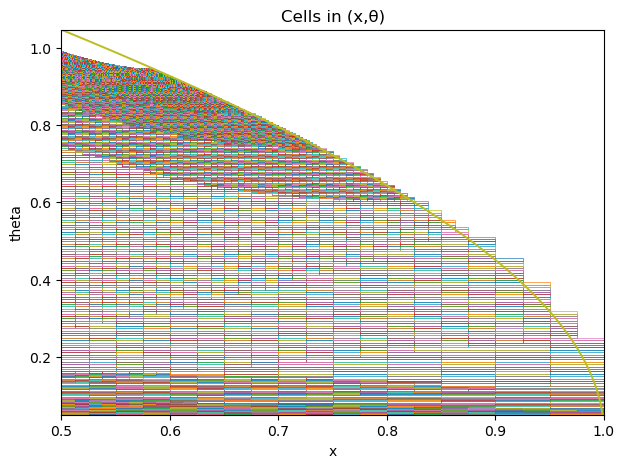

In [9]:
def plot_cells_xt(cells_scored, title="Cells in (x,θ)"):
    fig, ax = plt.subplots(figsize=(7,5))
    for cell,_ in cells_scored:
        x0,x1,t0,t1 = cell.xL, cell.xR, cell.tL, cell.tR
        ax.plot([x0,x1,x1,x0,x0], [t0,t0,t1,t1,t0], linewidth=0.5)
    xs = np.linspace(x_min, x_max, 600)
    ax.plot(xs, np.arccos(xs), linewidth=1.4)
    ax.set_xlabel("x")
    ax.set_ylabel("theta")
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(theta_low, theta_cap)
    plt.show()

def plot_cells_xy(cells_scored, title="Cells in (x,y)"):
    fig, ax = plt.subplots(figsize=(7,5))
    for cell,_ in cells_scored:
        verts = cell_vertices_xy(cell)
        ax.add_patch(Polygon(verts, closed=True, fill=False, linewidth=0.5))
    xs = np.linspace(x_min, x_max, 600)
    ys = np.sqrt(np.maximum(0.0, 1.0 - xs**2))
    ax.plot(xs, ys, linewidth=1.4)
    ax.plot([x_min, x_min], [0.0, math.sqrt(1.0-x_min**2)], linewidth=1.0)
    ax.plot(xs, 0*xs, linewidth=1.0)
    if exclude_eps_xy > 0.0:
        th = np.linspace(0, 2*math.pi, 400)
        ax.plot(PSTAR[0] + exclude_eps_xy*np.cos(th), PSTAR[1] + exclude_eps_xy*np.sin(th), linewidth=1.2)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_xlim(x_min-0.02, x_max+0.02)
    ax.set_ylim(-0.02, math.sqrt(1.0-x_min**2)+0.02)
    plt.show()

plot_cells_xt(cells_scored)
# plot_cells_xy(cells_scored)

## 9. Export CSV (your schema)

In [16]:
def export_cells_user_schema(path_csv: str, cells_scored):
    rows = []
    idx_out = 1
    for (cell, sc) in cells_scored:
        if not cell_intersects_Omega(cell):
            continue
        if exclude_eps_xy > 0.0 and cell_touches_excluded_ball(cell, exclude_eps_xy):
            continue
        rows.append({
            "i": idx_out,
            "x_inf": cell.xL,
            "x_sup": cell.xR,
            "theta_inf": cell.tL,
            "theta_sup": cell.tR,
            "mesh_size_upper": 0.002633,
            "fem_order_upper": 0.1249,
            "mesh_size_lower_cr": 0.04,
            "isLG": 1,
            "mesh_size_lower_LG": 0.1249,
            "fem_order_lower_LG": 4,
        })
        idx_out += 1

    df_out = pd.DataFrame(rows, columns=[
        "i","x_inf","x_sup","theta_inf","theta_sup",
        "mesh_size_upper","fem_order_upper","mesh_size_lower_cr","isLG","mesh_size_lower_LG","fem_order_lower_LG"
    ])
    df_out.to_csv(path_csv, index=False)
    print(f"Saved: {path_csv} (rows={len(df_out)})")
    return df_out

df_cells = export_cells_user_schema("cell_def.csv", cells_scored)
df_cells.head()

Saved: cell_def.csv (rows=34518)


,i,x_inf,x_sup,theta_inf,theta_sup,mesh_size_upper,fem_order_upper,mesh_size_lower_cr,isLG,mesh_size_lower_LG,fem_order_lower_LG
0,1,0.552344,0.552734,0.947090,0.947285,0.002633,0.1249,0.04,1,0.1249,4
1,2,0.552344,0.552734,0.947285,0.947480,0.002633,0.1249,0.04,1,0.1249,4
2,3,0.552734,0.553125,0.947090,0.947285,0.002633,0.1249,0.04,1,0.1249,4
3,4,0.552734,0.553125,0.947285,0.947480,0.002633,0.1249,0.04,1,0.1249,4
4,5,0.555469,0.555859,0.945532,0.945727,0.002633,0.1249,0.04,1,0.1249,4


## 10. Refinement history

In [11]:
df_hist = pd.DataFrame(history)
df_hist

,n_in,n_bad,n_good,split_cells,stuck_bad,n_out,round,min_J1_lb,min_J2_lb,time_sec,depth_max
0,20,20,0,20,0,38,0,-165.374900,-127.970369,0.048887,1
1,38,38,0,38,0,74,1,-151.244999,-113.840468,0.002791,2
2,74,74,0,74,0,143,2,-124.913978,-87.509446,0.003709,3
3,143,143,0,143,0,277,3,-89.013579,-51.609048,0.006199,4
4,277,277,0,277,0,543,4,-53.248618,-15.844087,0.011761,5
5,543,542,1,542,0,1066,5,-26.392940,-3.262138,0.022596,6
6,1066,979,87,979,0,2023,6,-25.481839,-0.631049,0.041281,7
7,2023,1260,763,1260,0,3269,7,-14.289084,-0.638722,0.074065,8
8,3269,1043,2226,1043,0,4279,8,-7.337095,-0.321389,0.157972,9
9,4279,1715,2564,1715,0,5970,9,-5.045581,-0.323587,0.147066,10


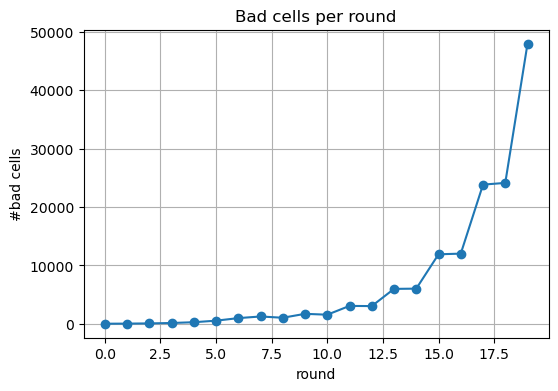

In [12]:
plt.figure(figsize=(6,4))
plt.plot(df_hist["round"], df_hist["n_bad"], marker="o")
plt.xlabel("round")
plt.ylabel("#bad cells")
plt.title("Bad cells per round")
plt.grid(True)
plt.show()

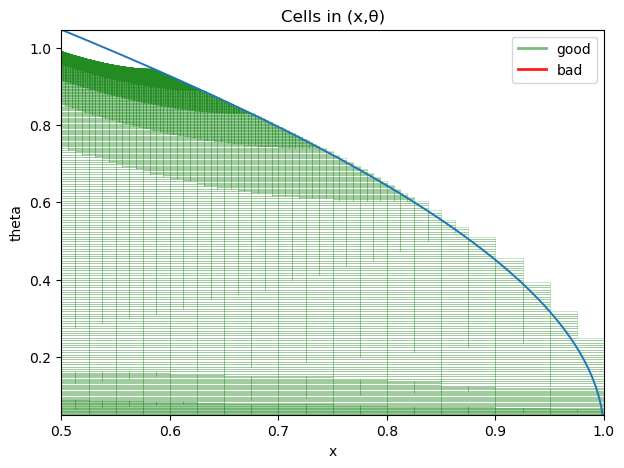

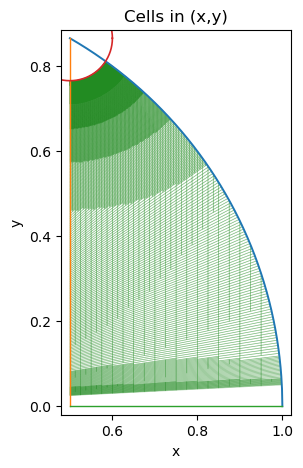

In [13]:
from matplotlib.lines import Line2D

def plot_cells_xt(cells_scored, title="Cells in (x,θ)"):
    fig, ax = plt.subplots(figsize=(7,5))

    bad_color  = "red"
    good_color = "forestgreen"

    for cell, sc in cells_scored:
        is_bad = cell_is_bad(sc)
        color = bad_color if is_bad else good_color
        alpha = 0.9 if is_bad else 0.35
        lw    = 0.8 if is_bad else 0.5

        x0, x1, t0, t1 = cell.xL, cell.xR, cell.tL, cell.tR
        ax.plot([x0,x1,x1,x0,x0], [t0,t0,t1,t1,t0], color=color, alpha=alpha, linewidth=lw)

    xs = np.linspace(x_min, x_max, 600)
    ax.plot(xs, np.arccos(xs), linewidth=1.4)

    ax.set_xlabel("x")
    ax.set_ylabel("theta")
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(theta_low, theta_cap)

    # legend（任意）
    ax.legend(handles=[
        Line2D([0],[0], color=good_color, lw=2, alpha=0.6, label="good"),
        Line2D([0],[0], color=bad_color,  lw=2, alpha=0.9, label="bad"),
    ], loc="upper right")

    plt.show()


def cell_polygon_xy_intersection(cell: CellXT, n_top: int = 40, eps_th: float = 1e-12):
    """
    Return polygon (Nx2 array) for (cell ∩ Ω) mapped into (x,y).
    If empty, return None.
    """
    # clip to x-range of Ω
    x0 = max(cell.xL, x_min)
    x1 = min(cell.xR, x_max)

    # further clip by feasibility of the *lower* theta: need tL < acos(x)  <=> x < cos(tL)
    x1 = min(x1, math.cos(cell.tL) - 1e-15)
    if x1 <= x0:
        return None

    tL, tR = cell.tL, cell.tR

    def y_bottom(x):
        return x * math.tan(tL)

    def y_top(x):
        th_cap = theta_max(x) - eps_th
        th = min(tR, th_cap)
        th = max(th, tL)  # guard (degenerate case)
        return x * math.tan(th)

    # vertices: BL -> BR -> TR -> (top boundary samples) -> TL
    BL = (x0, y_bottom(x0))
    BR = (x1, y_bottom(x1))
    TR = (x1, y_top(x1))
    TL = (x0, y_top(x0))

    # sample top boundary from right to left (exclude endpoints)
    xs_top = np.linspace(x1, x0, n_top + 2)[1:-1]
    top_pts = [(float(x), float(y_top(float(x)))) for x in xs_top]

    pts = [BL, BR, TR] + top_pts + [TL]
    return np.array(pts, dtype=float)


def plot_cells_xy(cells_scored, title="Cells in (x,y)"):
    fig, ax = plt.subplots(figsize=(7,5))

    bad_color  = "red"
    good_color = "forestgreen"

    for cell, sc in cells_scored:
        is_bad = cell_is_bad(sc)
        color = bad_color if is_bad else good_color
        alpha = 0.9 if is_bad else 0.35
        lw    = 0.8 if is_bad else 0.5

        poly = cell_polygon_xy_intersection(cell, n_top=50)
        if poly is None:
            continue
        ax.add_patch(Polygon(poly, closed=True, fill=False,
                             edgecolor=color, alpha=alpha, linewidth=lw))

    # Ω boundary
    xs = np.linspace(x_min, x_max, 600)
    ys = np.sqrt(np.maximum(0.0, 1.0 - xs**2))
    ax.plot(xs, ys, linewidth=1.4)
    ax.plot([x_min, x_min], [0.0, math.sqrt(1.0-x_min**2)], linewidth=1.0)
    ax.plot(xs, 0*xs, linewidth=1.0)

    if exclude_eps_xy > 0.0:
        th = np.linspace(0, 2*math.pi, 400)
        ax.plot(PSTAR[0] + exclude_eps_xy*np.cos(th),
                PSTAR[1] + exclude_eps_xy*np.sin(th), linewidth=1.2)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_xlim(x_min-0.02, x_max+0.02)
    ax.set_ylim(-0.02, math.sqrt(1.0-x_min**2)+0.02)
    plt.show()
    plt.show()


plot_cells_xt(cells_scored)
plot_cells_xy(cells_scored)